In [4]:
# 1. IMPORT LIBRARIES
!pip install optuna
!pip install catboost
import numpy as np
import pandas as pd
import json
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

import lightgbm as lgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

# 2. LOAD TRAIN DATA ONLY
# load processed data (after preprocessing step)
X_train = pd.read_csv("/content/X_train.csv")
y_train = pd.read_csv("/content/y_train.csv").values.ravel()

# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus'], drop_first=True)

print(X_train.shape, y_train.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00
(4504, 25) (4504,)


In [5]:
# 3. STRATIFIED K-FOLD
# keep same distribution of churn in each fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
# 4. OPTUNA OBJECTIVE - LIGHTGBM

def objective_lgb(trial):

    # ---- Suggest hyperparameters ----
    params = {
        "objective": "binary",
        "metric": "average_precision",  # PR-AUC
        "verbosity": -1,
        "boosting_type": "gbdt",

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),

        # handle imbalance
        "scale_pos_weight": (len(y_train) - sum(y_train)) / sum(y_train)
    }

    # ---- Cross-validation ----
    pr_auc_scores = []

    for train_idx, valid_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train[train_idx], y_train[valid_idx]

        # train model
        model = lgb.LGBMClassifier(**params, n_estimators=500)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        # predict probability
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # PR-AUC
        score = average_precision_score(y_val, y_pred_proba)
        pr_auc_scores.append(score)

    # return mean score across folds
    return np.mean(pr_auc_scores)

In [7]:
# 5. RUN OPTUNA - LIGHTGBM

study_lgb = optuna.create_study(direction="maximize")

study_lgb.optimize(objective_lgb, n_trials=30)

print("Best PR-AUC:", study_lgb.best_value)
print("Best params:", study_lgb.best_params)

[I 2026-04-27 14:54:46,731] A new study created in memory with name: no-name-a36fc3bc-8e24-4fd5-b981-5a90b9948e40
[I 2026-04-27 14:54:48,300] Trial 0 finished with value: 0.8539696721477774 and parameters: {'learning_rate': 0.07933763271071871, 'num_leaves': 53, 'max_depth': 3, 'feature_fraction': 0.8564743082699037, 'bagging_fraction': 0.8482220000842388, 'bagging_freq': 3, 'min_child_samples': 52}. Best is trial 0 with value: 0.8539696721477774.
[I 2026-04-27 14:54:52,034] Trial 1 finished with value: 0.9047686362073926 and parameters: {'learning_rate': 0.037339271147481784, 'num_leaves': 35, 'max_depth': 6, 'feature_fraction': 0.9927965223038294, 'bagging_fraction': 0.8188934022934997, 'bagging_freq': 1, 'min_child_samples': 65}. Best is trial 1 with value: 0.9047686362073926.
[I 2026-04-27 14:55:01,332] Trial 2 finished with value: 0.9222626851542192 and parameters: {'learning_rate': 0.049201432543737086, 'num_leaves': 104, 'max_depth': 9, 'feature_fraction': 0.7624267876285709, 'b

Best PR-AUC: 0.9442910822786725
Best params: {'learning_rate': 0.0811356948791168, 'num_leaves': 62, 'max_depth': 9, 'feature_fraction': 0.6006989469461671, 'bagging_fraction': 0.8558597513477519, 'bagging_freq': 9, 'min_child_samples': 17}


In [8]:
# 6. SAVE BEST PARAMS - LGB

with open("/content/best_params_lgb.json", "w") as f:
    json.dump(study_lgb.best_params, f, indent=4)

In [9]:
# 7. OPTUNA OBJECTIVE - CATBOOST

def objective_cb(trial):

    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "verbose": 0,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),

        "iterations": 500,

        # imbalance handling
        "class_weights": [
            1,
            (len(y_train) - sum(y_train)) / sum(y_train)
        ]
    }

    pr_auc_scores = []

    for train_idx, valid_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train[train_idx], y_train[valid_idx]

        model = CatBoostClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )

        y_pred_proba = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(y_val, y_pred_proba)
        pr_auc_scores.append(score)

    return np.mean(pr_auc_scores)

In [10]:
# 8. RUN OPTUNA - CATBOOST

study_cb = optuna.create_study(direction="maximize")

study_cb.optimize(objective_cb, n_trials=30)

print("Best PR-AUC:", study_cb.best_value)
print("Best params:", study_cb.best_params)

[I 2026-04-27 14:56:19,012] A new study created in memory with name: no-name-7317a027-7816-46f6-8497-528528b6a846
[I 2026-04-27 14:56:27,204] Trial 0 finished with value: 0.9447077601241747 and parameters: {'learning_rate': 0.09905892847970209, 'depth': 8, 'l2_leaf_reg': 5.332989615109022}. Best is trial 0 with value: 0.9447077601241747.
[I 2026-04-27 14:56:37,613] Trial 1 finished with value: 0.9267032841355087 and parameters: {'learning_rate': 0.07180389738361667, 'depth': 6, 'l2_leaf_reg': 9.329828433714175}. Best is trial 0 with value: 0.9447077601241747.
[I 2026-04-27 14:56:43,380] Trial 2 finished with value: 0.939409529927915 and parameters: {'learning_rate': 0.07270030263130771, 'depth': 7, 'l2_leaf_reg': 9.017827428626914}. Best is trial 0 with value: 0.9447077601241747.
[I 2026-04-27 14:56:47,771] Trial 3 finished with value: 0.9398057462512162 and parameters: {'learning_rate': 0.0695201448589665, 'depth': 7, 'l2_leaf_reg': 6.00862723092934}. Best is trial 0 with value: 0.944

Best PR-AUC: 0.9615304822746966
Best params: {'learning_rate': 0.05216130543848248, 'depth': 10, 'l2_leaf_reg': 4.889574516568033}


In [11]:
# 9. SAVE BEST PARAMS - CATBOOST

with open("/content/best_params_cb.json", "w") as f:
    json.dump(study_cb.best_params, f, indent=4)

/tmp/ipykernel_12247/4276276990.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_lgb)


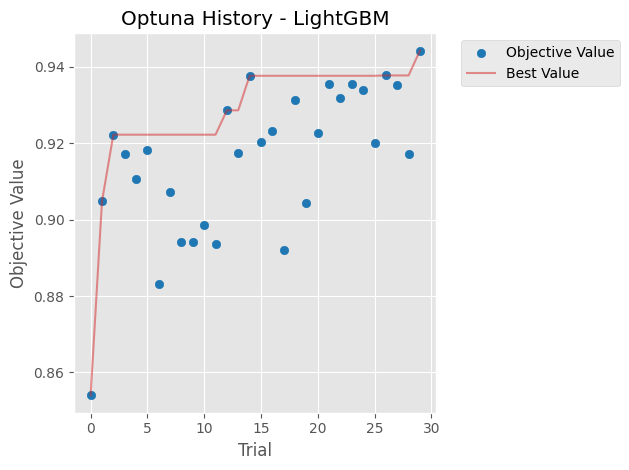

/tmp/ipykernel_12247/4276276990.py:10: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_cb)


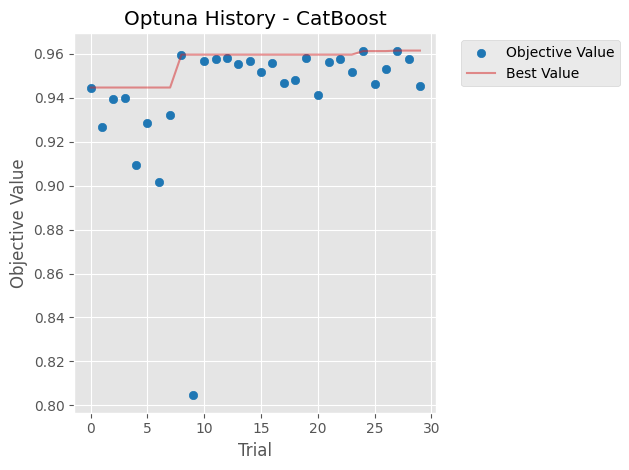

In [12]:
# 10. PLOT OPTUNA HISTORY

# LightGBM history
optuna.visualization.matplotlib.plot_optimization_history(study_lgb)
plt.title("Optuna History - LightGBM")
plt.savefig("/content/optuna_history_lgb.png")
plt.show()

# CatBoost history
optuna.visualization.matplotlib.plot_optimization_history(study_cb)
plt.title("Optuna History - CatBoost")
plt.savefig("/content/optuna_history_cb.png")
plt.show()